In [4]:
!pip install matplotlib seaborn



[notice] A new release of pip is available: 23.2.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# Setup and Data Loading

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load main datasets
orders = pd.read_csv(r"C:\Users\sathishkumar.ravi\Documents\data\blinkit_orders.csv")
order_items = pd.read_csv(r"C:\Users\sathishkumar.ravi\Documents\data\blinkit_order_items.csv")
customers = pd.read_csv(r"C:\Users\sathishkumar.ravi\Documents\data\blinkit_customers.csv")
feedback = pd.read_csv(r"C:\Users\sathishkumar.ravi\Documents\data\blinkit_customer_feedback.csv")

# Parse datetime columns
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['actual_delivery_time'] = pd.to_datetime(orders['actual_delivery_time'])
orders['promised_delivery_time'] = pd.to_datetime(orders['promised_delivery_time'])


#  Data Cleaning


In [12]:
# Check for nulls
print(orders.isnull().sum())

# Fill or drop based on strategy
orders['payment_method'] = orders['payment_method'].fillna('Unknown')
orders.dropna(subset=['order_total', 'order_date'], inplace=True)

# Clean delivery times
orders['delivery_time_minutes'] = (
    orders['actual_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

# Remove negative delivery times if any
orders = orders[orders['delivery_time_minutes'] >= 0]


order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
delivery_status           0
order_total               0
payment_method            0
delivery_partner_id       0
store_id                  0
dtype: int64


# EDA Distribution Visuals

In [13]:
# Summary statistics
print(orders[['order_total', 'delivery_time_minutes']].describe())


       order_total  delivery_time_minutes
count   5000.00000            5000.000000
mean    2201.86170              19.434400
std     1303.02438               8.659486
min       13.25000               5.000000
25%     1086.21500              13.000000
50%     2100.69000              18.000000
75%     3156.88250              24.000000
max     6721.46000              50.000000


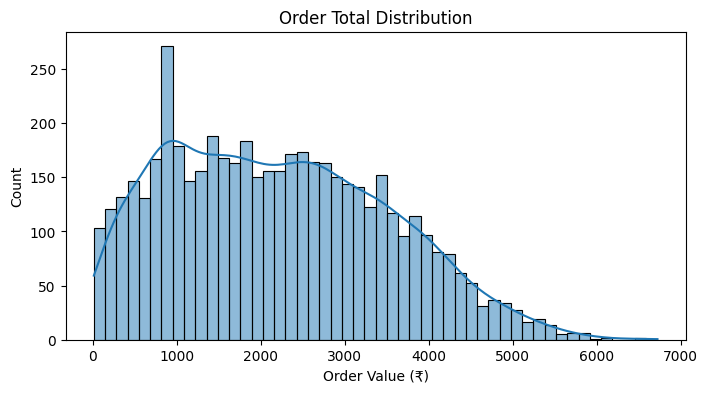

In [14]:
plt.figure(figsize=(8, 4))
sns.histplot(orders['order_total'], bins=50, kde=True)
plt.title("Order Total Distribution")
plt.xlabel("Order Value (₹)")
plt.show()


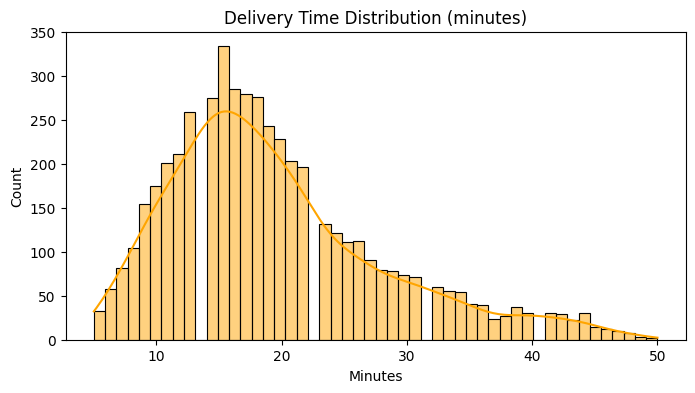

In [15]:
plt.figure(figsize=(8, 4))
sns.histplot(orders['delivery_time_minutes'], bins=50, kde=True, color='orange')
plt.title("Delivery Time Distribution (minutes)")
plt.xlabel("Minutes")
plt.show()


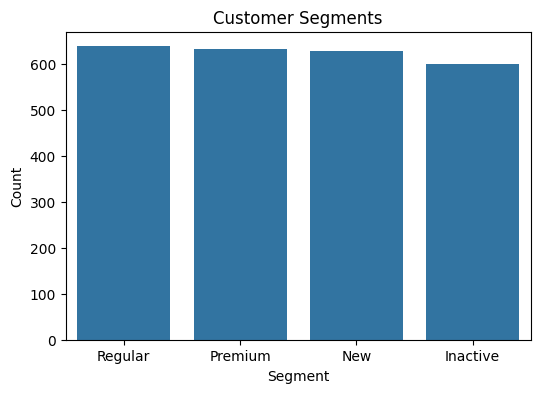

In [16]:
plt.figure(figsize=(6, 4))
sns.countplot(data=customers, x='customer_segment', order=customers['customer_segment'].value_counts().index)
plt.title("Customer Segments")
plt.xlabel("Segment")
plt.ylabel("Count")
plt.show()


In [17]:
feedback = pd.read_csv("C:\\blinkit_dataset\\blinkit_customer_feedback.csv")
feedback.head()


,feedback_id,order_id,customer_id,rating,feedback_text,feedback_category,sentiment,feedback_date
0,2234710,1961864118,30065862,4,"It was okay, nothing special.",Delivery,Neutral,2024-07-17
1,5450964,1549769649,9573071,3,The order was incorrect.,App Experience,Negative,2024-05-28
2,482108,9185164487,45477575,3,"It was okay, nothing special.",App Experience,Neutral,2024-09-23
3,4823104,9644738826,88067569,4,The product met my expectations.,App Experience,Neutral,2023-11-24
4,3537464,5427684290,83298567,3,Product was damaged during delivery.,Delivery,Negative,2023-11-20


# Text Cleaning & Sentiment Analysis


In [6]:
import re

# Fill missing feedbacks with blank string
feedback['feedback_text'] = feedback['feedback_text'].fillna('')

# Basic cleaning: remove punctuation, numbers, and lowercase
def clean_text(text):
    text = re.sub(r"[^a-zA-Z\s]", "", text)  # remove special characters & digits
    text = text.lower()  # lowercase
    return text

feedback['cleaned_feedback'] = feedback['feedback_text'].apply(clean_text)


C:\Users\sathi\AppData\Local\Temp\ipykernel_24272\543946030.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="magma")


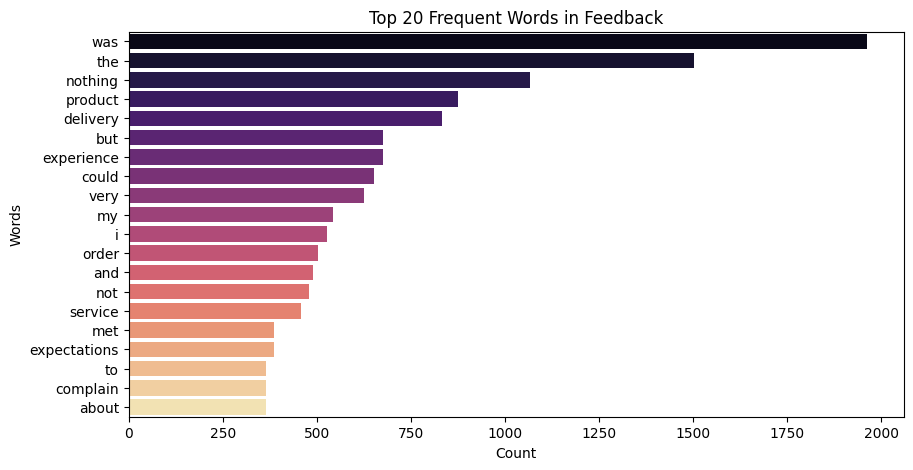

In [19]:
from collections import Counter

all_words = " ".join(feedback['cleaned_feedback']).split()
word_freq = Counter(all_words)
common_words = word_freq.most_common(20)

# Plot top 20 words
import matplotlib.pyplot as plt

words, counts = zip(*common_words)
plt.figure(figsize=(10, 5))
sns.barplot(x=list(counts), y=list(words), palette="magma")
plt.title("Top 20 Frequent Words in Feedback")
plt.xlabel("Count")
plt.ylabel("Words")
plt.show()


In [21]:
!pip install textblob
from textblob import TextBlob

# Get polarity score for each feedback
feedback['sentiment_score'] = feedback['feedback_text'].apply(lambda x: TextBlob(x).sentiment.polarity)



[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


   ---------------------------------------- 0.0/624.3 kB ? eta -:--:--
   ---------------------------------------- 624.3/624.3 kB 3.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ------------- -------------------------- 0.5/1.5 MB 3.3 MB/s eta 0:00:01
   ---------------------------------- ----- 1.3/1.5 MB 3.3 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 3.2 MB/s eta 0:00:00


# Correlation with Orders

In [22]:
merged = pd.merge(feedback, orders, on='order_id', how='inner')

# Correlation between sentiment and order total
print("Correlation with Order Total:", merged['sentiment_score'].corr(merged['order_total']))

# Correlation with delivery time
print("Correlation with Delivery Time (min):", merged['sentiment_score'].corr(merged['delivery_time_minutes']))


Correlation with Order Total: -0.004284071969796587
Correlation with Delivery Time (min): -0.01805711975314813


# Delivery Time Prediction (Regression)

In [25]:
!pip install scikit-learn



   ---------------------------------------- 0.0/10.7 MB ? eta -:--:--
   - -------------------------------------- 0.5/10.7 MB 3.3 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/10.7 MB 3.2 MB/s eta 0:00:03
   ------ --------------------------------- 1.8/10.7 MB 3.2 MB/s eta 0:00:03
   --------- ------------------------------ 2.6/10.7 MB 3.2 MB/s eta 0:00:03
   ----------- ---------------------------- 3.1/10.7 MB 3.2 MB/s eta 0:00:03
   -------------- ------------------------- 3.9/10.7 MB 3.2 MB/s eta 0:00:03
   ----------------- ---------------------- 4.7/10.7 MB 3.2 MB/s eta 0:00:02
   ------------------- -------------------- 5.2/10.7 MB 3.2 MB/s eta 0:00:02
   ---------------------- ----------------- 6.0/10.7 MB 3.2 MB/s eta 0:00:02
   ------------------------ --------------- 6.6/10.7 MB 3.2 MB/s eta 0:00:02
   --------------------------- ------------ 7.3/10.7 MB 3.2 MB/s eta 0:00:02
   ----------------------------- ---------- 7.9/10.7 MB 3.2 MB/s eta 0:00:01
   ---


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
import pandas as pd

# Make sure you have delivery duration calculated
orders['promised_duration_minutes'] = (
    orders['promised_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

orders['delivery_time_minutes'] = (
    orders['actual_delivery_time'] - orders['order_date']
).dt.total_seconds() / 60

# Remove negative values if any
orders = orders[(orders['delivery_time_minutes'] >= 0) & (orders['promised_duration_minutes'] > 0)]


In [36]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
orders['delivery_partner_encoded'] = le.fit_transform(orders['delivery_partner_id'])


In [34]:
features = orders[['promised_duration_minutes', 'delivery_partner_encoded']]
target = orders['delivery_time_minutes']


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)


In [30]:
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", round(mae, 2))
print("R² Score:", round(r2, 2))


MAE: 6.07
R² Score: 0.12


In [31]:
coefficients = pd.DataFrame({
    'Feature': features.columns,
    'Coefficient': model.coef_
})
print(coefficients)


                     Feature  Coefficient
0  promised_duration_minutes     1.016469
1   delivery_partner_encoded     0.000168


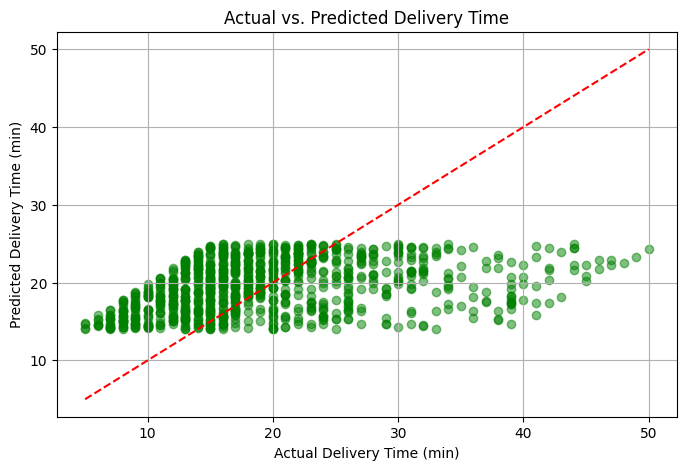

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Delivery Time (min)")
plt.ylabel("Predicted Delivery Time (min)")
plt.title("Actual vs. Predicted Delivery Time")
plt.grid(True)
plt.show()


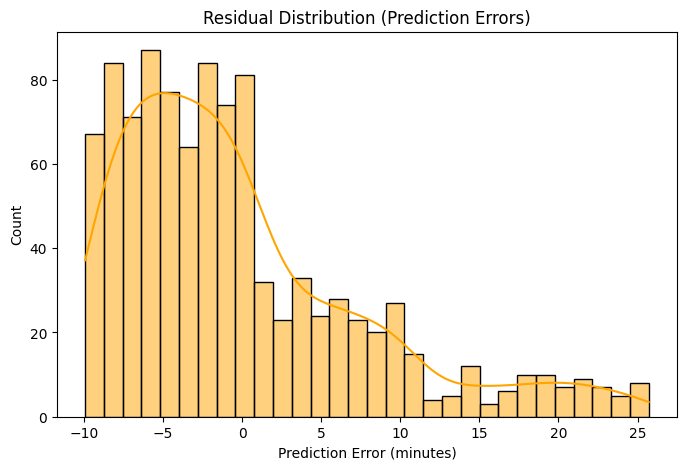

In [39]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=30, kde=True, color='orange')
plt.title("Residual Distribution (Prediction Errors)")
plt.xlabel("Prediction Error (minutes)")
plt.show()


In [40]:
# Aggregate order frequency and average order value
customer_summary = orders.groupby('customer_id').agg({
    'order_id': 'count',
    'order_total': 'mean'
}).rename(columns={
    'order_id': 'order_count',
    'order_total': 'avg_order_value'
}).reset_index()

customer_summary.head()


,customer_id,order_count,avg_order_value
0,31813,2,2863.020000
1,61020,3,2614.966667
2,119099,4,3692.192500
3,188838,2,2591.020000
4,191616,2,2044.980000


In [41]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(customer_summary[['order_count', 'avg_order_value']])


In [42]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
customer_summary['cluster'] = kmeans.fit_predict(scaled_data)


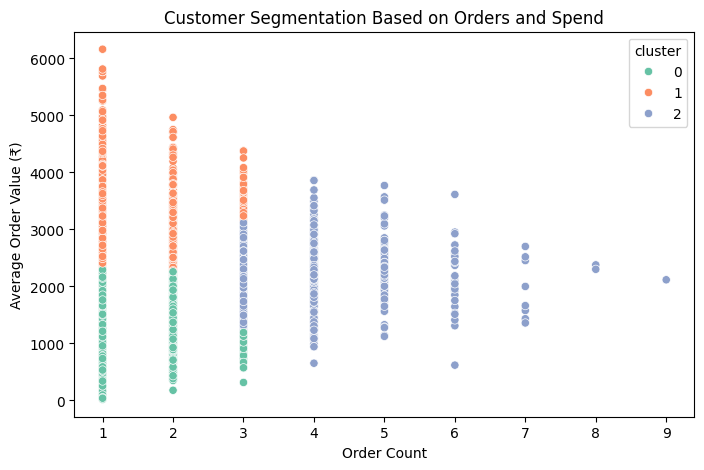

In [43]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=customer_summary, 
    x='order_count', 
    y='avg_order_value', 
    hue='cluster', 
    palette='Set2'
)
plt.title("Customer Segmentation Based on Orders and Spend")
plt.xlabel("Order Count")
plt.ylabel("Average Order Value (₹)")
plt.show()


In [45]:
cluster_profile = customer_summary.groupby('cluster')[['order_count', 'avg_order_value']].mean()
print(cluster_profile)


         order_count  avg_order_value
cluster                              
0           1.563291      1316.946110
1           1.625943      3236.757469
2           3.737135      2192.180460


In [46]:
# Make sure date is datetime
orders['order_date'] = pd.to_datetime(orders['order_date'])

# Create a Year-Month column
orders['year_month'] = orders['order_date'].dt.to_period('M')

# Group by Year-Month
monthly_sales = orders.groupby('year_month')['order_total'].sum().reset_index()
monthly_sales['year_month'] = monthly_sales['year_month'].astype(str)
monthly_sales.head()


,year_month,order_total
0,2023-03,272878.96
1,2023-04,554344.77
2,2023-05,608213.54
3,2023-06,505227.66
4,2023-07,567639.91


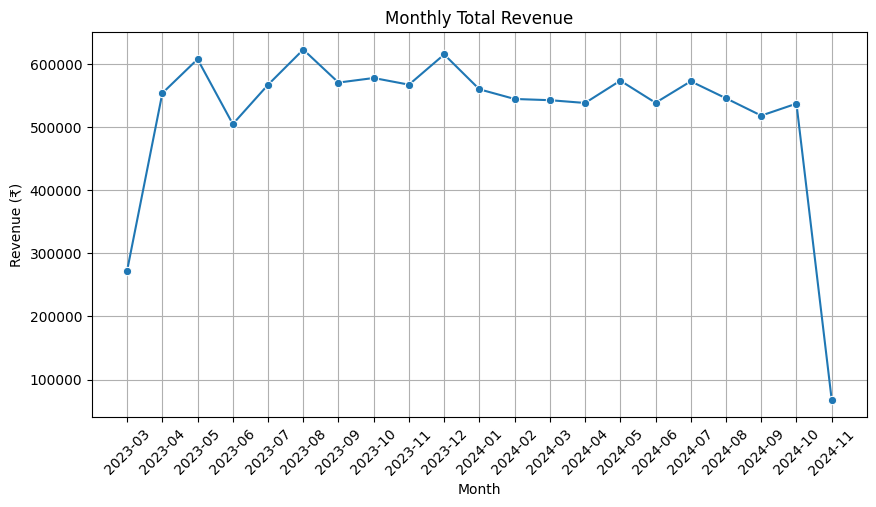

In [47]:
plt.figure(figsize=(10, 5))
sns.lineplot(data=monthly_sales, x='year_month', y='order_total', marker='o')
plt.title("Monthly Total Revenue")
plt.xticks(rotation=45)
plt.ylabel("Revenue (₹)")
plt.xlabel("Month")
plt.grid(True)
plt.show()


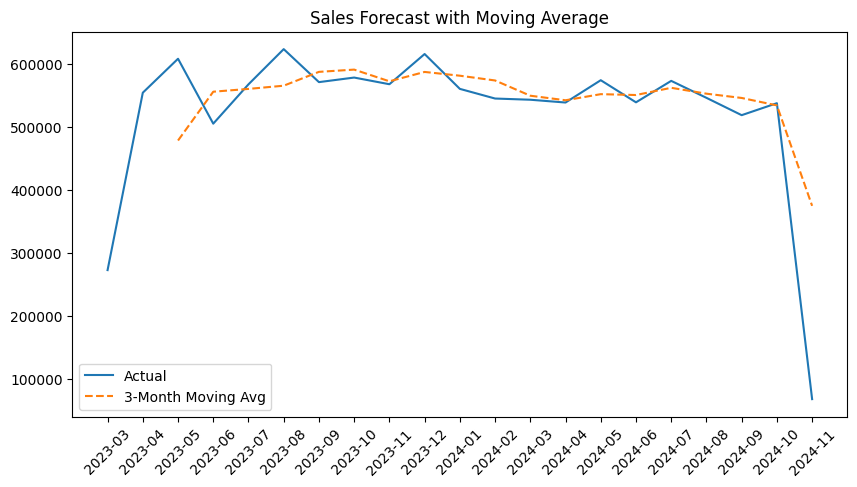

In [48]:
monthly_sales['forecast'] = monthly_sales['order_total'].rolling(window=3).mean()

plt.figure(figsize=(10, 5))
plt.plot(monthly_sales['year_month'], monthly_sales['order_total'], label='Actual')
plt.plot(monthly_sales['year_month'], monthly_sales['forecast'], label='3-Month Moving Avg', linestyle='--')
plt.xticks(rotation=45)
plt.legend()
plt.title("Sales Forecast with Moving Average")
plt.show()
